In [179]:
import librosa as lb
import matplotlib.pyplot as plt
import librosa.display as lbd
import numpy as np
import soundfile as sf

### Загрузка файла

In [180]:
file = 'lab_sound/file.mp3'
signal, sr = lb.load(file, sr = None)

###  Выводим график сигнала в амплитудно-временной форме

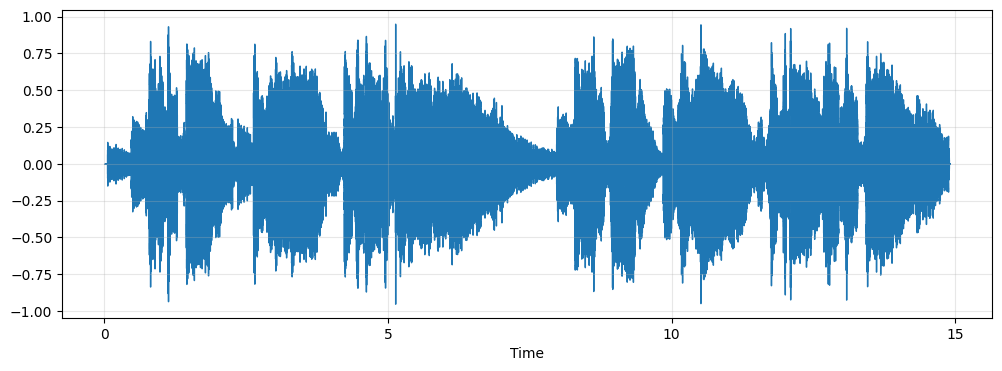

In [181]:
plt.figure(figsize=(12,4))
plt.grid(alpha=0.3)
lbd.waveshow(signal, sr=sr)

### Преобразование Фурье

In [182]:
X = lb.stft(signal)
s = lb.amplitude_to_db(abs(X))
spectrum_db = np.mean(s, axis=1)
freqs = lb.fft_frequencies(sr=sr)

### Отрисовка частотного спектра

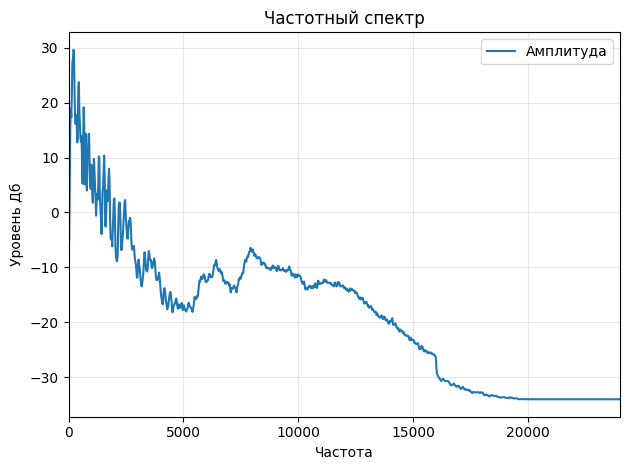

In [183]:
plt.plot(freqs, spectrum_db, label='Амплитуда')

plt.xlabel("Частота")
plt.ylabel("Уровень Дб")
plt.title("Частотный спектр")
plt.xlim(0, sr/2)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Отрисовка спекторгаммы

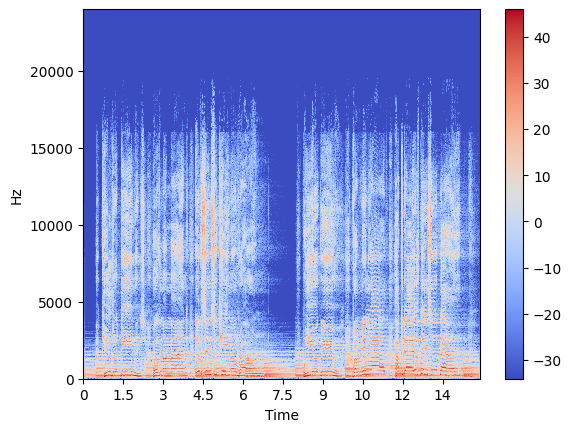

In [184]:
lbd.specshow(s, sr=sr, x_axis = 'time', y_axis='linear')
plt.colorbar()

In [185]:
info = sf.info(file)

In [186]:
tempo, beat_frames = lb.beat.beat_track(y=signal, sr=sr)
beat_time = lb.frames_to_time(beat_frames, sr=sr)

In [187]:
f"Частота дискретизации: {sr}, значение темпа: {tempo[0]:.4f}"

'Частота дискретизации: 48000, значение темпа: 89.2857'

In [188]:
f"Количество бит: {len(beat_time)}, количество каналов: {info.channels}"

'Количество бит: 22, количество каналов: 2'

### Что такое гармоническая и перкуссионная часть сигнала? Для чего они нужны?

Гармоническая часть сигнала - это часть сигнала, которая звучит долго и плавно на опредеенной высоте.
Энергия сосредоточена в узком диапозоне частот, а сам сигнал имеет почти периодическую структуру. Проще говоря, это певучие элементы, которые можно пропеть.

Перкуссионная часть сигнала - это часть сигнала, которая звучит резко и кратко. Энергия распределена по широкому диапозону частот, но по узкому диапозону времени. Обычно это ударные, импульсные элементы, которые можно отстучать.

Они нужны для того, чтобы определять темп и ритм, распозновать мелодии и аккорды, обрабатывать звук, усиливая, ослабляя, отчищая отдельные части звукозаписи. Помогают музыкантам в написании ремиксов, да и в целом при написании музыки.